In [60]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

C:\Users\laura\AppData\Local\Temp\ipykernel_64808\3777615979.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


# Lab | Natural Language Processing
### SMS: SPAM or HAM

### Let's prepare the environment

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

- Read Data for the Fraudulent Email Kaggle Challenge
- Reduce the training set to speead up development. 

In [62]:
## Read Data for the Fraudulent Email Kaggle Challenge
data = pd.read_csv("../data/kg_train.csv",encoding='latin-1')

# Reduce the training set to speed up development. 
# Modify for final system
data = data.head(1000)
print(data.shape)
data.fillna("",inplace=True)

(1000, 2)


### Let's divide the training and test set into two partitions

In [63]:
data.head()

,text,label
0,"DEAR SIR, STRICTLY A PRIVATE BUSINESS PROPOSAL...",1
1,Will do.,0
2,Nora--Cheryl has emailed dozens of memos about...,0
3,Dear Sir=2FMadam=2C I know that this proposal ...,1
4,fyi,0


In [64]:
from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split

X = data['text']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # preserve spam/ham ratio in both splits
)

## Data Preprocessing

In [65]:
import string
from nltk.corpus import stopwords
print(string.punctuation)
print(stopwords.words("english")[100:110])
from nltk.stem.snowball import SnowballStemmer
snowball = SnowballStemmer('english')

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
['needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on']


## Now, we have to clean the html code removing words

- First we remove inline JavaScript/CSS
- Then we remove html comments. This has to be done before removing regular tags since comments can contain '>' characters
- Next we can remove the remaining tags

In [66]:
import re

def clean_html(text):
    # 1. Remove inline JavaScript/CSS
    text = re.sub(r'<(script|style)[^>]*>.*?</(script|style)>', '', text, flags=re.DOTALL | re.IGNORECASE)
    
    # 2. Remove HTML comments (before tags, since comments can contain '>')
    text = re.sub(r'<!--.*?-->', '', text, flags=re.DOTALL)
    
    # 3. Remove remaining HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    
    return text

data['text'] = data['text'].apply(clean_html)

- Remove all the special characters
    
- Remove numbers
    
- Remove all single characters
 
- Remove single characters from the start

- Substitute multiple spaces with single space

- Remove prefixed 'b'

- Convert to Lowercase

In [67]:
def clean_text(text):
    # 1. Remove special characters
    text = re.sub(r'\W', ' ', text)

    # 2. Remove numbers
    text = re.sub(r'\d', ' ', text)

    # 3. Remove single characters
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)

    # 4. Remove single characters from the start
    text = re.sub(r'^[a-zA-Z]\s+', ' ', text)

    # 5. Substitute multiple spaces with single space
    text = re.sub(r'\s+', ' ', text, flags=re.I)

    # 6. Remove prefixed 'b' (artifact from Python byte strings like b'text')
    text = re.sub(r'^b\s+', '', text)

    # 7. Convert to lowercase
    text = text.lower()

    return text

data['text'] = data['text'].apply(clean_text)

In [68]:
data.head()

,text,label
0,dear sir strictly private business proposal am...,1
1,will do,0
2,nora cheryl has emailed dozens of memos about ...,0
3,dear sir fmadam i know that this proposal migh...,1
4,fyi,0


## Now let's work on removing stopwords
Remove the stopwords.

In [69]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered = [word for word in words if word not in stop_words]
    return ' '.join(filtered)

data['text'] = data['text'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\laura\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Tame Your Text with Lemmatization
Break sentences into words, then use lemmatization to reduce them to their base form (e.g., "running" becomes "run"). See how this creates cleaner data for analysis!

In [70]:
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    lemmatized = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized)

data['text'] = data['text'].apply(lemmatize_text)

print(data['text'].head())

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\laura\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


0    dear sir strictly private business proposal mi...
1                                                     
2    nora cheryl emailed dozen memo haiti weekend p...
3    dear sir fmadam know proposal might surprise e...
4                                                  fyi
Name: text, dtype: object


## Bag Of Words
Let's get the 10 top words in ham and spam messages (**EXPLORATORY DATA ANALYSIS**)

In [71]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_words(df, label, n=10):
    # Filter by label
    corpus = df[df['label'] == label]['text']
    
    # Create Bag of Words
    vectorizer = CountVectorizer(max_features=1000)
    bow = vectorizer.fit_transform(corpus)
    
    # Sum word frequencies and get top n
    word_freq = dict(zip(vectorizer.get_feature_names_out(), bow.toarray().sum(axis=0)))
    top_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:n]
    
    return top_words

# Get top 10 words for ham (0) and spam (1)
top_ham  = get_top_words(data, label=0)
top_spam = get_top_words(data, label=1)

print("Top 10 HAM words:")
for word, freq in top_ham:
    print(f"  {word}: {freq}")

print("\nTop 10 SPAM words:")
for word, freq in top_spam:
    print(f"  {word}: {freq}")

Top 10 HAM words:
  state: 136
  pm: 127
  would: 107
  president: 99
  time: 95
  call: 94
  mr: 91
  obama: 84
  percent: 81
  secretary: 79

Top 10 SPAM words:
  money: 981
  account: 895
  bank: 800
  fund: 781
  transaction: 549
  business: 514
  country: 508
  mr: 487
  nbsp: 475
  million: 460


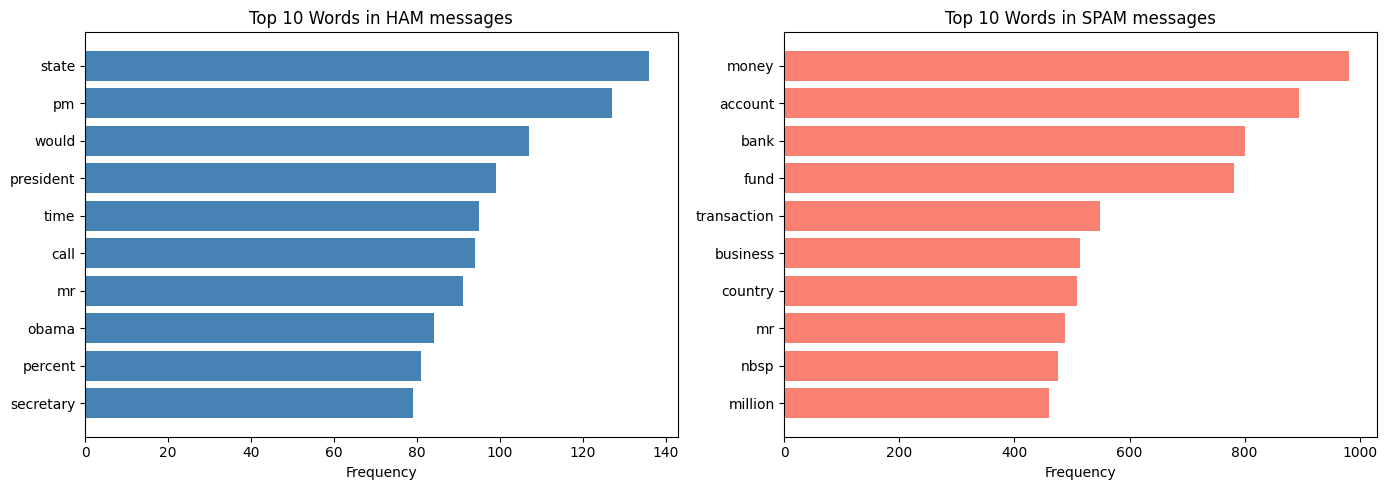

In [72]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# HAM
ham_words, ham_freq = zip(*top_ham)
axes[0].barh(ham_words[::-1], ham_freq[::-1], color='steelblue')
axes[0].set_title('Top 10 Words in HAM messages')
axes[0].set_xlabel('Frequency')

# SPAM
spam_words, spam_freq = zip(*top_spam)
axes[1].barh(spam_words[::-1], spam_freq[::-1], color='salmon')
axes[1].set_title('Top 10 Words in SPAM messages')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

## Extra features

In [73]:
data = data.rename(columns={'text': 'preprocessed_text'})

data_train, data_val = train_test_split(
    data,
    test_size=0.2,
    random_state=42,
    stratify=data['label']
)

data_train = data_train.reset_index(drop=True)
data_val = data_val.reset_index(drop=True)

In [74]:
# We add to the original dataframe two additional indicators (money symbols and suspicious words).
money_simbol_list = "|".join(["euro","dollar","pound","€",r"\$"])
suspicious_words = "|".join(["free","cheap","sex","money","account","bank","fund","transfer","transaction","win","deposit","password"])

data_train['money_mark'] = data_train['preprocessed_text'].str.contains(money_simbol_list)*1
data_train['suspicious_words'] = data_train['preprocessed_text'].str.contains(suspicious_words)*1
data_train['text_len'] = data_train['preprocessed_text'].apply(lambda x: len(x)) 

data_val['money_mark'] = data_val['preprocessed_text'].str.contains(money_simbol_list)*1
data_val['suspicious_words'] = data_val['preprocessed_text'].str.contains(suspicious_words)*1
data_val['text_len'] = data_val['preprocessed_text'].apply(lambda x: len(x)) 

data_train.head()

,preprocessed_text,label,money_mark,suspicious_words,text_len
0,dear good day hope fine cdear writting mail du...,1,1,1,1002
1,mr henry kaborethe chief auditor inchargeforei...,1,0,1,2015
2,,0,0,0,0
3,desk dr adamu ismalerauditing accounting manag...,1,1,1,383
4,dear friend name loi estrada wife mr josephest...,1,1,1,1475


## How would work the Bag of Words with Count Vectorizer concept?

In [75]:
from sklearn.feature_extraction.text import CountVectorizer
import scipy.sparse as sp
import numpy as np

# Fit CountVectorizer on training set only
count_vectorizer = CountVectorizer(max_features=3000)
X_train_bow = count_vectorizer.fit_transform(data_train['preprocessed_text'])
X_val_bow   = count_vectorizer.transform(data_val['preprocessed_text'])

print(f"BoW Train shape: {X_train_bow.shape}")
print(f"BoW Val shape:   {X_val_bow.shape}")

BoW Train shape: (800, 3000)
BoW Val shape:   (200, 3000)


## TF-IDF

- Load the vectorizer

- Vectorize all dataset

- print the shape of the vetorized dataset

In [76]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=3000)

# Vectorize — fit on train, transform both splits
X_train_tfidf = tfidf_vectorizer.fit_transform(data_train['preprocessed_text'])
X_val_tfidf   = tfidf_vectorizer.transform(data_val['preprocessed_text'])

# Print shapes
print(f"TF-IDF Train shape: {X_train_tfidf.shape}")
print(f"TF-IDF Val shape:   {X_val_tfidf.shape}")

TF-IDF Train shape: (800, 3000)
TF-IDF Val shape:   (200, 3000)


## And the Train a Classifier?

In [77]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

y_train = data_train['label']
y_val   = data_val['label']

# Train on TF-IDF features
clf = MultinomialNB()
clf.fit(X_train_tfidf, y_train)

# Evaluate
y_pred = clf.predict(X_val_tfidf)
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['HAM', 'SPAM']))

Accuracy: 0.9850

Classification Report:
              precision    recall  f1-score   support

         HAM       1.00      0.97      0.99       112
        SPAM       0.97      1.00      0.98        88

    accuracy                           0.98       200
   macro avg       0.98      0.99      0.98       200
weighted avg       0.99      0.98      0.99       200



### Extra Task - Implement a SPAM/HAM classifier

https://www.kaggle.com/t/b384e34013d54d238490103bc3c360ce

The classifier can not be changed!!! It must be the MultinimialNB with default parameters!

Your task is to **find the most relevant features**.

For example, you can test the following options and check which of them performs better:
- Using "Bag of Words" only
- Using "TF-IDF" only
- Bag of Words + extra flags (money_mark, suspicious_words, text_len)
- TF-IDF + extra flags


You can work with teams of two persons (recommended).

In [78]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
import scipy.sparse as sp
import numpy as np

# Extra flags (need to be non-negative for MultinomialNB)
extra_train = data_train[['money_mark', 'suspicious_words', 'text_len']].values
extra_val   = data_val[['money_mark', 'suspicious_words', 'text_len']].values

# Scale text_len to [0,1] so it doesn't dominate
scaler = MinMaxScaler()
extra_train = scaler.fit_transform(extra_train)
extra_val   = scaler.transform(extra_val)

results = {}

# --- Option 1: BoW only ---
clf = MultinomialNB()
clf.fit(X_train_bow, y_train)
results['BoW only'] = accuracy_score(y_val, clf.predict(X_val_bow))

# --- Option 2: TF-IDF only ---
clf = MultinomialNB()
clf.fit(X_train_tfidf, y_train)
results['TF-IDF only'] = accuracy_score(y_val, clf.predict(X_val_tfidf))

# --- Option 3: BoW + extra flags ---
X_train_bow_extra = sp.hstack([X_train_bow, extra_train])
X_val_bow_extra   = sp.hstack([X_val_bow,   extra_val])
clf = MultinomialNB()
clf.fit(X_train_bow_extra, y_train)
results['BoW + extra flags'] = accuracy_score(y_val, clf.predict(X_val_bow_extra))

# --- Option 4: TF-IDF + extra flags ---
X_train_tfidf_extra = sp.hstack([X_train_tfidf, extra_train])
X_val_tfidf_extra   = sp.hstack([X_val_tfidf,   extra_val])
clf = MultinomialNB()
clf.fit(X_train_tfidf_extra, y_train)
results['TF-IDF + extra flags'] = accuracy_score(y_val, clf.predict(X_val_tfidf_extra))

# --- Print results ---
print("Feature Combination Comparison (MultinomialNB):")
print("-" * 45)
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:<30} Accuracy: {acc:.4f}")

best = max(results, key=results.get)
print(f"\nBest combination: {best} ({results[best]:.4f})")

Feature Combination Comparison (MultinomialNB):
---------------------------------------------
  TF-IDF only                    Accuracy: 0.9850
  BoW only                       Accuracy: 0.9750
  BoW + extra flags              Accuracy: 0.9750
  TF-IDF + extra flags           Accuracy: 0.9650

Best combination: TF-IDF only (0.9850)
